In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

In [2]:
import warnings
warnings.filterwarnings("ignore")

#### data processing

In [3]:
data_path = "../data/"
output_path = "../output/"

In [4]:
data = pd.read_csv(data_path + "diabetes_130_full.csv", low_memory = False)

##### mapping

In [5]:
### Assign relevant item mapping to id from csv

IDs_mapping = pd.read_csv(data_path + "IDS_mapping.csv")

admission_id_mapping = IDs_mapping.iloc[:8, :]
admission_id_mapping['admission_type_id'] = admission_id_mapping['admission_type_id'].astype(int)
admission_id_mapping = admission_id_mapping.set_index('admission_type_id')['description'].to_dict()

discharge_id_mapping = IDs_mapping.iloc[10:40, :]
discharge_id_mapping['admission_type_id'] = discharge_id_mapping['admission_type_id'].astype(int)
discharge_id_mapping = discharge_id_mapping.set_index('admission_type_id')['description'].to_dict()

admission_source_id_mapping = IDs_mapping.iloc[42:, :]
admission_source_id_mapping['admission_type_id'] = admission_source_id_mapping['admission_type_id'].astype(int)
admission_source_id_mapping = admission_source_id_mapping.set_index('admission_type_id')['description'].to_dict()

data['admission_type_id'] = data['admission_type_id'].map(admission_id_mapping)
data['discharge_disposition_id'] = data['discharge_disposition_id'].map(discharge_id_mapping)
data['admission_source_id'] = data['admission_source_id'].map(admission_source_id_mapping)

In [6]:
def map_diag_category(code):
    """
    Map ICD-9 diagnosis codes to broad disease categories.
    Returns 'Unknown' for missing or unrecognized codes.
    Based on wikipedia: https://en.wikipedia.org/wiki/List_of_ICD-9_codes
    """
    if pd.isna(code):
        return "Other / Unknown"

    # Try converting to float if it's numeric
    try:
        code = float(str(code).split('.')[0])
    except:
        return "Other / Unknown"

    # Now safe to compare numerically
    if 1 <= code <= 139:
        return 'Infectious & Parasitic'
    elif 140 <= code <= 239:
        return 'Neoplasms'
    elif 249 <= code < 251:
        return "Diabetes mellitus"
    elif 240 <= code <= 279:
        return 'Endocrine / Metabolic / Immunity'
    elif 280 <= code <= 289:
        return 'Blood & Blood-forming Organs'
    elif 290 <= code <= 319:
        return 'Mental Disorders'
    elif 320 <= code <= 389:
        return 'Nervous System'
    elif 390 <= code <= 459:
        return 'Circulatory System'
    elif 460 <= code <= 519:
        return 'Respiratory System'
    elif 520 <= code <= 579:
        return 'Digestive System'
    elif 580 <= code <= 629:
        return 'Genitourinary System'
    elif 630 <= code <= 679:
        return 'Pregnancy / Childbirth'
    elif 680 <= code <= 709:
        return 'Skin & Subcutaneous Tissue'
    elif 710 <= code <= 739:
        return 'Musculoskeletal System'
    elif 740 <= code <= 759:
        return 'Congenital Anomalies'
    elif 760 <= code <= 779:
        return 'Perinatal Conditions'
    elif 780 <= code <= 799:
        return 'Symptoms / Ill-defined Conditions'
    elif 800 <= code <= 999:
        return 'Injury & Poisoning'
    else:
        return 'Other / Unknown'

# Apply mapping to diagnosis columns
data['diag_1_category'] = data['diag_1'].apply(map_diag_category)

In [7]:
# Fill NaN and ensure lowercase strings
data['discharge_disposition_category'] = (
    data['discharge_disposition_id']
    .fillna('unknown')
    .astype(str)
    .str.lower()
)

conditions = [
    data['discharge_disposition_id'].str.lower().str.contains('hospice', na=False),
    data['discharge_disposition_id'].str.lower().str.contains('home', na=False),
    data['discharge_disposition_id'].str.lower().str.contains('outpatient|still patient', na=False),
    data['discharge_disposition_id'].str.lower().str.contains('ama|admitted|inpatient', na=False),
    data['discharge_disposition_id'].str.lower().str.contains('hospital|rehab|swing bed|snf|icf|nursing|psychiatric|federal', na=False),
]

choices = [
    'hospice',
    'home',
    'outpatient',
    'inpatient',
    'hospital / facility'
]

data['discharge_disposition_category'] = np.select(conditions, choices, default='other')

print(data['discharge_disposition_category'].value_counts())

discharge_disposition_category
home                   73244
hospital / facility    19563
other                   6322
inpatient               1828
hospice                  781
outpatient                28
Name: count, dtype: int64


##### Feature engineering

In [8]:
#Total procedures
data['total_procedures'] = (
    data['num_lab_procedures'] + data['num_procedures'] + data['num_medications']
)

#Ratio features
data['lab_med_ratio'] = data['num_lab_procedures'] / (data['num_medications'] + 1)

In [9]:
data.drop(columns = ['Unnamed: 0'], axis = 1, inplace = True)

In [10]:
## drop repeated encounters, only keep the first. 

data.sort_values(by = ['encounter_id'], inplace = True)
data = data.drop_duplicates(subset='patient_nbr', keep='first')      

In [11]:
data = data[data['gender'].isin(['Female', 'Male'])]  # drop 3 rows, small missing

In [12]:
data = data[~data['discharge_disposition_id'].str.lower().str.contains('expired', na=False)]  # patient who are expired, unable to get readmission according to the data.

In [13]:
data['insulin'] = data['insulin'].replace({'Up': 'Change', 'Down': 'Change'})

### Features Removal

##### Remove features with 75% missing, unless the missing refer to 'Not Taken' such as Test Results

In [14]:
# Missing Analysis (% Missing)

missing_results = data.isnull().sum() / len(data)

print("\nVariables with any missing values (descending)")
missing_results[missing_results > 0.75].sort_values(ascending = False)


Variables with any missing values (descending)


weight           0.960046
max_glu_serum    0.951939
A1Cresult        0.817154
dtype: float64

In [15]:
data.drop(columns = ['weight'], axis = 1, inplace = True)

We will keep the <strong>max_glu_serum</strong> and <strong>A1Cresult</strong> as these are test results -- missing just refer to patients who did not take the test. <br>This itself carry valuable information in the context of diabetic readmission

##### Remove features with no inherent relationship to diabetic readmission

In [16]:
data.drop(columns = ['admission_source_id', 
                     'payer_code', 
                     'medical_specialty',
                     'encounter_id', 
                     'patient_nbr'], axis = 1, inplace = True)

##### Remove features with low cardinality (i.e., >= 95% same value)

In [17]:
threshold = 0.95  # 95%

unique_ratio = data.nunique() / len(data)
dominant_ratio = data.apply(lambda col: col.value_counts(normalize=True).iloc[0])
low_variance_cols = dominant_ratio[dominant_ratio >= threshold].index.tolist()
print("Low-variance columns (≥95% same value):")
print(low_variance_cols)

Low-variance columns (≥95% same value):
['repaglinide', 'nateglinide', 'chlorpropamide', 'acetohexamide', 'tolbutamide', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']


In [18]:
data.drop(columns = low_variance_cols, axis = 1, inplace = True)

In [19]:
mapping = {'NO': 0, '>30': 0, '<30': 1}
data['readmitted_binary'] = data['readmitted'].map(mapping)   # predicting short term readmission risk

In [20]:
data.drop(columns = ['readmitted'], axis = 1, inplace = True)

In [21]:
data = data.fillna("None")

In [22]:
data.shape

(70431, 32)

### replace 0 values with 0.0001 for polynomials interactive terms

In [23]:
import pandas as pd
from itertools import combinations

# target columns
cols = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses'
]

# Step 1: Replace 0 values with 0.0001
data[cols] = data[cols].replace(0, 0.0001)

# Step 2: Create polynomial interaction terms (pairwise products)
for col1, col2 in combinations(cols, 2):
    new_col = f"{col1} {col2}"
    data[new_col] = data[col1] * data[col2]

##### Remove features with low cardinality (i.e., >= 95% same value)

In [24]:
threshold = 0.95  # 95%

unique_ratio = data.nunique() / len(data)
dominant_ratio = data.apply(lambda col: col.value_counts(normalize=True).iloc[0])
low_variance_cols = dominant_ratio[dominant_ratio >= threshold].index.tolist()
print("Low-variance columns (≥95% same value):")
print(low_variance_cols)

Low-variance columns (≥95% same value):
['max_glu_serum']


In [25]:
data.drop(columns = low_variance_cols, axis = 1, inplace = True)

In [26]:
X = data.drop(['readmitted_binary'], axis = 1)
y = data['readmitted_binary']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

### Single Factor Analysis (WoE and IV) only on the Train to avoid Data Leakage

In [28]:
def woe_discrete(X, y, categorical_var):
    # Combine X and y temporarily inside the function
    df = X.copy()
    df['Bad'] = y.values  # y must be aligned index-wise with X

    WoE_results = pd.DataFrame()
    WoE_results[categorical_var] = df[categorical_var].astype(str).fillna('Missing')
    WoE_results['Bad'] = df['Bad']

    # Count and mean (bad rate)
    Count = WoE_results.groupby(categorical_var).count().reset_index()
    Mean = WoE_results.groupby(categorical_var).mean().reset_index()

    result = pd.concat([Count, Mean], axis=1).iloc[:, [0, 1, 3]]
    result.columns = [categorical_var, 'n_obs', 'prop_bad']

    # Compute stats
    result['prop_good'] = 1 - result['prop_bad']
    result['n_bad'] = result['prop_bad'] * result['n_obs']
    result['n_good'] = result['prop_good'] * result['n_obs']
    result['prop_n_bad'] = result['n_bad'] / result['n_bad'].sum()
    result['prop_n_good'] = result['n_good'] / result['n_good'].sum()

    # WoE & IV
    result['WoE'] = np.log((result['prop_n_good'] + 1e-10) / (result['prop_n_bad'] + 1e-10))
    result['%Good - %Bad'] = result['prop_n_good'] - result['prop_n_bad']
    result['IV'] = result['WoE'] * result['%Good - %Bad']
    result['IV'] = result['IV'].sum()
    result['prop_total'] = result['n_obs'] / result['n_obs'].sum()

    # Sort bins (numerically if possible)
    try:
        result[categorical_var] = result[categorical_var].astype(float)
        result.sort_values(by=categorical_var, inplace=True)
    except ValueError:
        result.sort_values(by=categorical_var, inplace=True)

    result.reset_index(drop=True, inplace=True)
    return result

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()                               

def plot_by_woe(df, rotation_of_x_axis_labels = 0):
    x = np.array(df.iloc[:, 0].apply(str))            
    y = df['WoE']
    plt.figure(figsize=(18, 6))
    plt.plot(x, y, marker = 'o', linestyle = '--', color = 'k')
    plt.xlabel(df.columns[0])
    plt.ylabel('Weight of Evidence')
    plt.title(str('Weight of Evidence by ' + df.columns[0]), fontsize=14, fontweight='bold')
    plt.xticks(rotation = rotation_of_x_axis_labels)

In [30]:
Categorical_var = X_train.select_dtypes(include='object').columns.tolist()
Categorical_var = [col for col in Categorical_var if col != 'readmitted']
print("Categorical columns:\n")
print(Categorical_var)

Categorical columns:

['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'diag_1', 'diag_2', 'diag_3', 'A1Cresult', 'metformin', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin', 'change', 'diabetesMed', 'diag_1_category', 'discharge_disposition_category']


In [31]:
iv_dict = {}

for var in Categorical_var:
    result_df = woe_discrete(X_train, y_train, var)
    iv_value = result_df['IV'].iloc[0] 
    iv_dict[var] = iv_value

iv_dict = dict(sorted(iv_dict.items(), key=lambda x: x[1], reverse=True))

for k, v in iv_dict.items():
    print(f"{k}: {v:.4f}")

diag_1: 0.7425
diag_3: 0.6386
diag_2: 0.6208
discharge_disposition_id: 0.1846
discharge_disposition_category: 0.1180
age: 0.0296
diag_1_category: 0.0289
diabetesMed: 0.0167
insulin: 0.0110
admission_type_id: 0.0080
race: 0.0044
change: 0.0038
glipizide: 0.0030
metformin: 0.0013
glimepiride: 0.0009
rosiglitazone: 0.0007
pioglitazone: 0.0006
A1Cresult: 0.0006
glyburide: 0.0004
gender: 0.0003


### Ordinal Categorical

### Age

In [32]:
woe_discrete(X_train, y_train, 'age')

,age,n_obs,prop_bad,prop_good,n_bad,n_good,prop_n_bad,prop_n_good,WoE,%Good - %Bad,IV,prop_total
0,[0-10),99,0.030303,0.969697,3.0,96.0,0.000681,0.002138,1.144127,0.001457,0.029559,0.002008
1,[10-20),381,0.052493,0.947507,20.0,361.0,0.004540,0.008041,0.571537,0.003501,0.029559,0.007728
2,[20-30),803,0.069738,0.930262,56.0,747.0,0.012713,0.016638,0.269105,0.003926,0.029559,0.016288
3,[30-40),1873,0.069407,0.930593,130.0,1743.0,0.029512,0.038823,0.274220,0.009311,0.029559,0.037991
4,[40-50),4821,0.075296,0.924704,363.0,4458.0,0.082406,0.099296,0.186444,0.016890,0.029559,0.097787
5,[50-60),8576,0.072994,0.927006,626.0,7950.0,0.142111,0.177076,0.219968,0.034965,0.029559,0.173952
6,[60-70),11072,0.088602,0.911398,981.0,10091.0,0.222701,0.224764,0.009218,0.002062,0.029559,0.224580
7,[70-80),12469,0.102494,0.897506,1278.0,11191.0,0.290125,0.249265,-0.151795,-0.040860,0.029559,0.252916
8,[80-90),7960,0.104397,0.895603,831.0,7129.0,0.188649,0.158789,-0.172312,-0.029860,0.029559,0.161457
9,[90-100),1247,0.093825,0.906175,117.0,1130.0,0.026561,0.025169,-0.053809,-0.001391,0.029559,0.025294


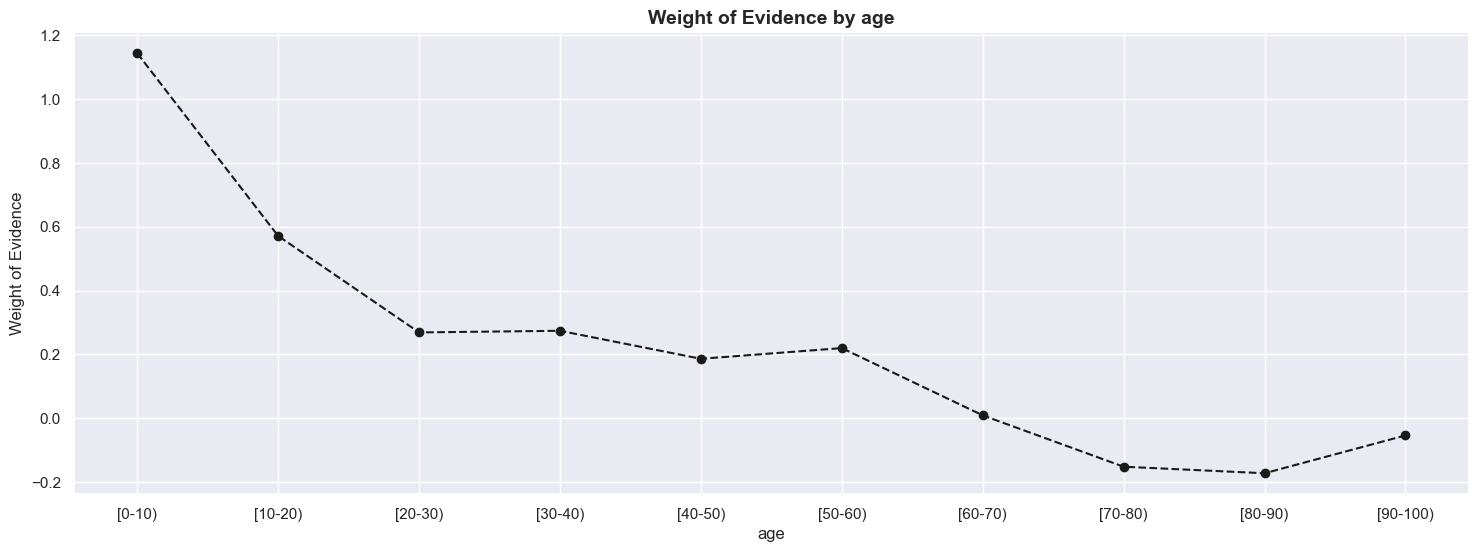

In [33]:
plot_by_woe(woe_discrete(X_train, y_train, 'age'))

In [34]:
age_order = [
    '[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
    '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)'
]

# Create a mapping dictionary: bin → ordinal number
age_mapping = {age: i+1 for i, age in enumerate(age_order)}

# Apply the mapping
X_train['age_encoded'] = X_train['age'].map(age_mapping)
print(X_train[['age', 'age_encoded']])        

           age  age_encoded
15796  [70-80)            8
91253  [30-40)            4
3377   [70-80)            8
16822  [60-70)            7
57752  [60-70)            7
...        ...          ...
819    [40-50)            5
31852  [40-50)            5
92538  [60-70)            7
45895  [70-80)            8
60652  [60-70)            7

[49301 rows x 2 columns]


## Nominal Categorical

### Discharge disposition

In [35]:
woe_discrete(X_train, y_train, 'discharge_disposition_category').sort_values(by = ['prop_bad'], ascending = False)

,discharge_disposition_category,n_obs,prop_bad,prop_good,n_bad,n_good,prop_n_bad,prop_n_good,WoE,%Good - %Bad,IV,prop_total
3,inpatient,942,0.158174,0.841826,149.0,793.0,0.033825,0.017663,-0.649732,-0.016162,0.118042,0.019107
2,hospital / facility,8970,0.147046,0.852954,1319.0,7651.0,0.299432,0.170416,-0.563646,-0.129016,0.118042,0.181944
4,other,2286,0.093176,0.906824,213.0,2073.0,0.048354,0.046173,-0.046148,-0.002181,0.118042,0.046368
5,outpatient,11,0.090909,0.909091,1.0,10.0,0.000227,0.000223,-0.019023,-0.000004,0.118042,0.000223
0,home,36778,0.073767,0.926233,2713.0,34065.0,0.615891,0.758754,0.208607,0.142863,0.118042,0.745989
1,hospice,314,0.031847,0.968153,10.0,304.0,0.002270,0.006771,1.092834,0.004501,0.118042,0.006369


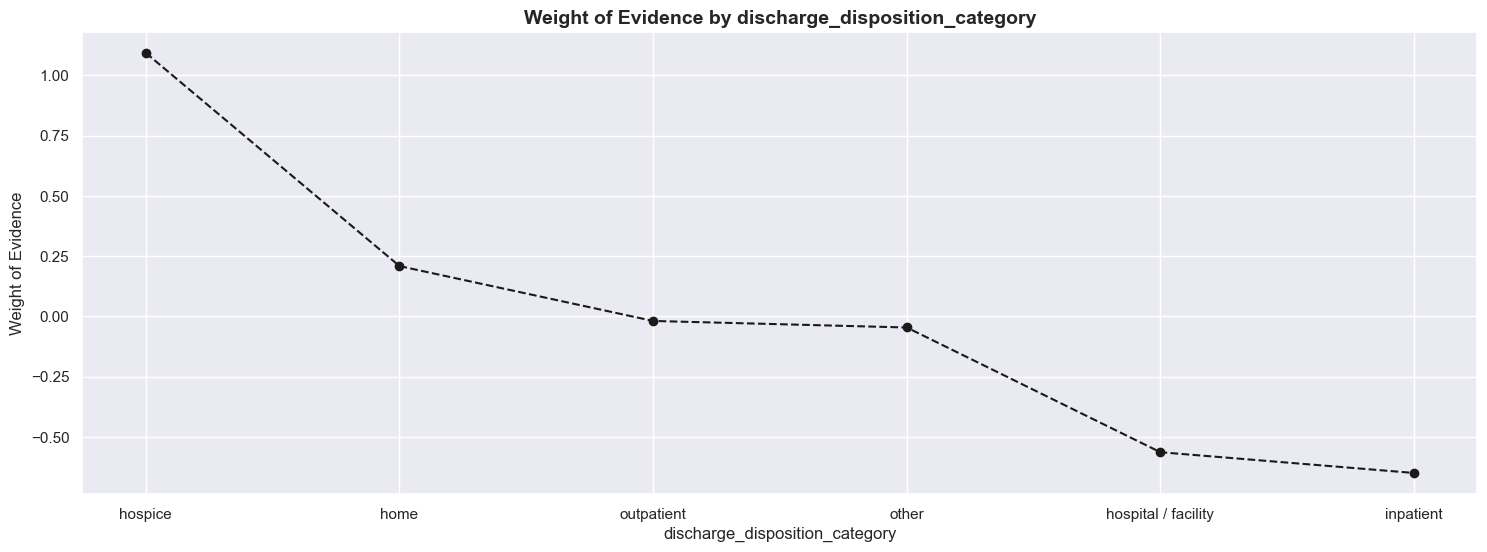

In [36]:
plot_by_woe(woe_discrete(X_train, y_train, 'discharge_disposition_category').sort_values(by = ['WoE'], ascending = False))

In [37]:
discharge_order = {
    'hospice': 0,          # 3.18% readmission - lowest risk
    'home': 1,             # 7.38% readmission
    'outpatient': 2,            # 9.32% readmission  
    'other': 2,       # 9.09% readmission (small sample, treat cautiously)
    'hospital / facility': 3, # 14.70% readmission
    'inpatient': 4         # 15.82% readmission - highest risk
}

In [38]:
X_train['discharge_disposition_ord'] = X_train['discharge_disposition_category'].map(discharge_order)

## Numerical Variables

In [39]:
num_features = [col for col in data.columns if data[col].dtype != 'object']

In [40]:
num_features.remove('readmitted_binary')

In [41]:
iv_dict = {}

list_of_good_numerical = []

for col in num_features:
    binned = col
    if X_train[col].nunique() > 15:
        binned = f"{col}_bin"
        X_train[binned] = pd.qcut(X_train[col], q=10, duplicates='drop')
    result = woe_discrete(X_train, y_train, binned)  # ✅ only pass the column name
    iv_dict[col] = result['IV'].iloc[0]

# sort and display
iv_dict = dict(sorted(iv_dict.items(), key=lambda x: x[1], reverse=True))
for k, v in iv_dict.items():
    if v >= 0.02:   
        print(f"{k}: {v:.4f}")
        list_of_good_numerical.append(k)

time_in_hospital number_inpatient: 0.1085
num_medications number_inpatient: 0.0892
number_inpatient: 0.0883
number_inpatient number_diagnoses: 0.0870
num_lab_procedures number_inpatient: 0.0791
number_emergency number_inpatient: 0.0588
time_in_hospital number_emergency: 0.0554
time_in_hospital number_diagnoses: 0.0511
time_in_hospital: 0.0453
time_in_hospital number_outpatient: 0.0450
time_in_hospital num_medications: 0.0448
time_in_hospital num_lab_procedures: 0.0392
num_procedures number_inpatient: 0.0388
num_medications number_diagnoses: 0.0383
num_medications number_emergency: 0.0378
number_outpatient number_inpatient: 0.0340
number_emergency number_diagnoses: 0.0321
num_lab_procedures num_medications: 0.0305
num_medications number_outpatient: 0.0284
num_lab_procedures number_diagnoses: 0.0270
num_medications: 0.0263
num_lab_procedures number_emergency: 0.0248
number_outpatient number_diagnoses: 0.0238
number_diagnoses: 0.0219
total_procedures: 0.0212


#### Time in hospital x Number inpatient

In [42]:
X_train['time_in_hospital number_inpatient'].nunique()

64

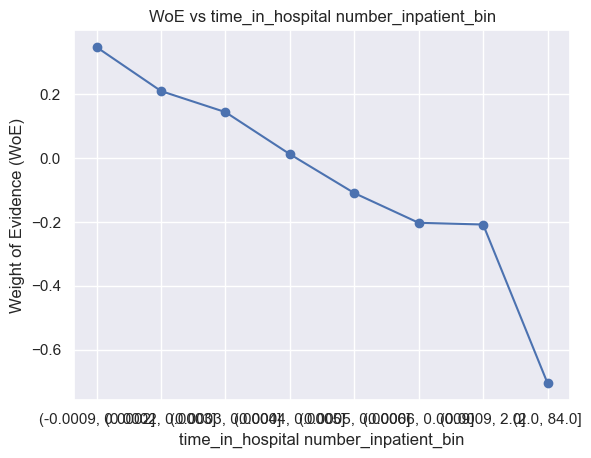

In [43]:
factor = 'time_in_hospital number_inpatient_bin'

result = woe_discrete(X_train, y_train, factor)

result_sorted = result.copy()
result_sorted[factor] = result_sorted[factor]
result_sorted = result_sorted.sort_values(factor)

plt.plot(result_sorted[factor], result_sorted['WoE'], marker='o')
plt.xlabel(factor)
plt.ylabel('Weight of Evidence (WoE)')
plt.title(f'WoE vs {factor}')
plt.show()  


#### Num medications x number inpatient

In [44]:
X_train['num_medications number_inpatient'].nunique()

206

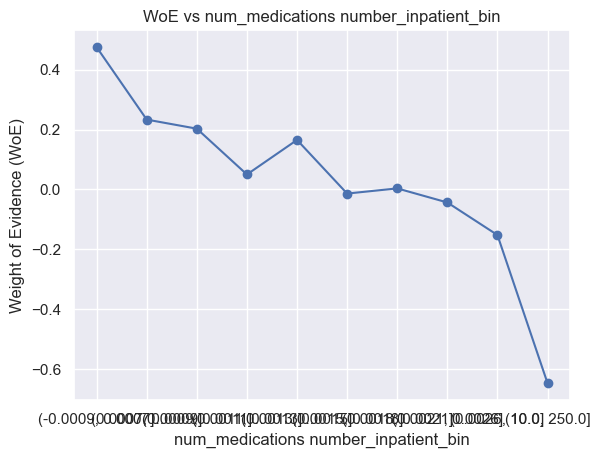

In [45]:
factor = 'num_medications number_inpatient_bin'

result = woe_discrete(X_train, y_train, factor)

result_sorted = result.copy()
result_sorted[factor] = result_sorted[factor]
result_sorted = result_sorted.sort_values(factor)

plt.plot(result_sorted[factor], result_sorted['WoE'], marker='o')
plt.xlabel(factor)
plt.ylabel('Weight of Evidence (WoE)')
plt.title(f'WoE vs {factor}')
plt.show()  


### number_inpatient number_diagnoses

In [46]:
X_train['number_inpatient number_diagnoses'].nunique()

54

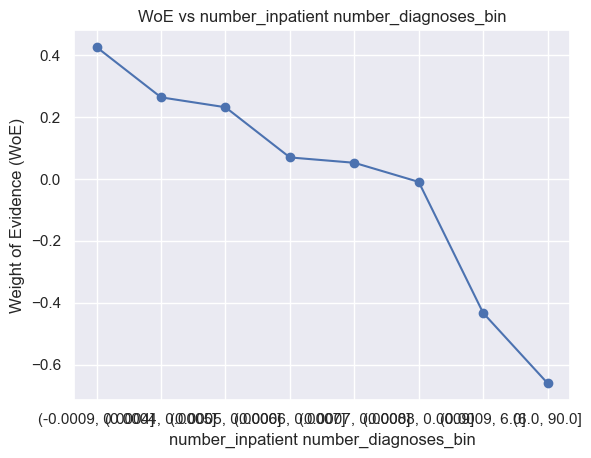

In [47]:
factor = 'number_inpatient number_diagnoses_bin'

result = woe_discrete(X_train, y_train, factor)

result_sorted = result.copy()
result_sorted[factor] = result_sorted[factor]
result_sorted = result_sorted.sort_values(factor)

plt.plot(result_sorted[factor], result_sorted['WoE'], marker='o')
plt.xlabel(factor)
plt.ylabel('Weight of Evidence (WoE)')
plt.title(f'WoE vs {factor}')
plt.show()  


#### num_lab_procedures number_inpatient

In [48]:
X_train['num_lab_procedures number_inpatient'].nunique()

388

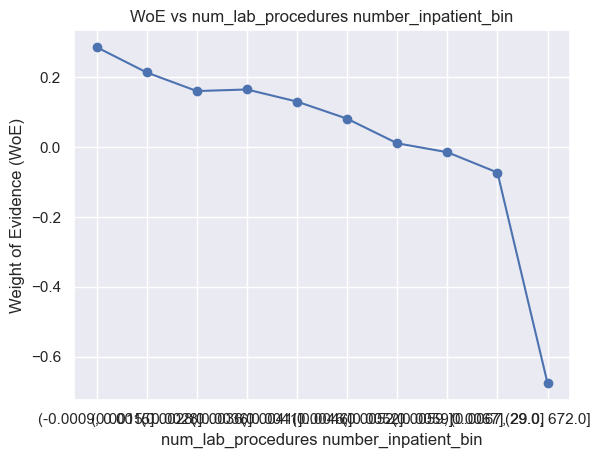

In [49]:
factor = 'num_lab_procedures number_inpatient_bin'

result = woe_discrete(X_train, y_train, factor)

result_sorted = result.copy()
result_sorted[factor] = result_sorted[factor]
result_sorted = result_sorted.sort_values(factor)

plt.plot(result_sorted[factor], result_sorted['WoE'], marker='o')
plt.xlabel(factor)
plt.ylabel('Weight of Evidence (WoE)')
plt.title(f'WoE vs {factor}')
plt.show()  


### Number of inpatient

In [50]:
woe_discrete(X_train, y_train, 'number_inpatient')

,number_inpatient,n_obs,prop_bad,prop_good,n_bad,n_good,prop_n_bad,prop_n_good,WoE,%Good - %Bad,IV,prop_total
0,0.0001,43595,0.080858,0.919142,3525.0,40070.0,0.800227,0.892507,0.109139,0.092280,0.088334,0.884262
1,1.0000,4006,0.126560,0.873440,507.0,3499.0,0.115096,0.077936,-0.389887,-0.037161,0.088334,0.081256
2,2.0000,1060,0.188679,0.811321,200.0,860.0,0.045403,0.019155,-0.862993,-0.026248,0.088334,0.021501
3,3.0000,329,0.237082,0.762918,78.0,251.0,0.017707,0.005591,-1.152864,-0.012116,0.088334,0.006673
4,4.0000,167,0.257485,0.742515,43.0,124.0,0.009762,0.002762,-1.262527,-0.007000,0.088334,0.003387
5,5.0000,77,0.311688,0.688312,24.0,53.0,0.005448,0.001181,-1.529370,-0.004268,0.088334,0.001562
6,6.0000,35,0.400000,0.600000,14.0,21.0,0.003178,0.000468,-1.916143,-0.002710,0.088334,0.000710
7,7.0000,15,0.600000,0.400000,9.0,6.0,0.002043,0.000134,-2.727073,-0.001909,0.088334,0.000304
8,8.0000,9,0.222222,0.777778,2.0,7.0,0.000454,0.000156,-1.068845,-0.000298,0.088334,0.000183
9,9.0000,6,0.333333,0.666667,2.0,4.0,0.000454,0.000089,-1.628460,-0.000365,0.088334,0.000122


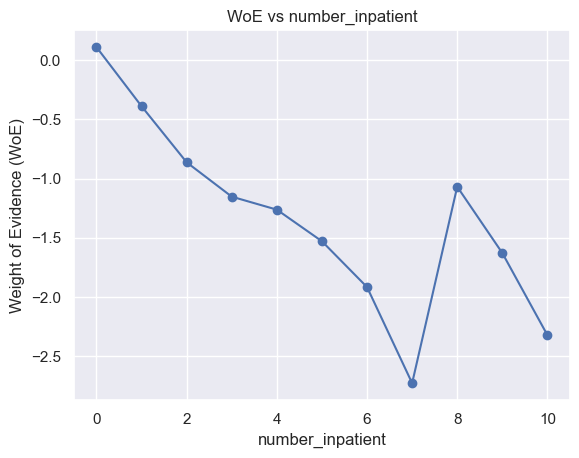

In [51]:
result = woe_discrete(X_train, y_train, 'number_inpatient')

result_sorted = result.copy()
result_sorted['number_inpatient'] = result_sorted['number_inpatient'].astype(float)
result_sorted = result_sorted.sort_values('number_inpatient')

plt.plot(result_sorted['number_inpatient'], result_sorted['WoE'], marker='o')
plt.xlabel('number_inpatient')
plt.ylabel('Weight of Evidence (WoE)')
plt.title('WoE vs number_inpatient')
plt.show()  

## can see that 8,9,10 show volatile. This is due to small sample that caused the random noise!! 

In [52]:
X_train['number_inpatient'] = X_train['number_inpatient'].clip(upper=7)

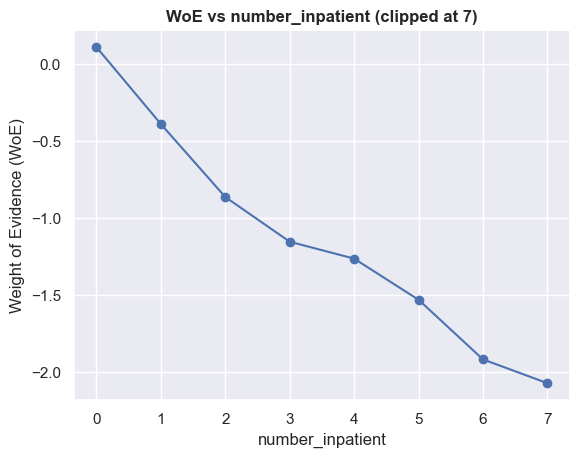

In [53]:
result = woe_discrete(X_train, y_train, 'number_inpatient')

result_sorted = result.copy()
result_sorted['number_inpatient'] = result_sorted['number_inpatient'].astype(float)
result_sorted = result_sorted.sort_values('number_inpatient')

plt.plot(result_sorted['number_inpatient'], result_sorted['WoE'], marker='o')
plt.xlabel('number_inpatient')
plt.ylabel('Weight of Evidence (WoE)')
plt.title('WoE vs number_inpatient (clipped at 7)', fontsize=12, fontweight = 'bold')
plt.show()  

## can see that 8,9,10 show volatile. This is due to small sample that caused the random noise!! 

In [54]:
woe_discrete(X_train, y_train, 'number_inpatient')

,number_inpatient,n_obs,prop_bad,prop_good,n_bad,n_good,prop_n_bad,prop_n_good,WoE,%Good - %Bad,IV,prop_total
0,0.0001,43595,0.080858,0.919142,3525.0,40070.0,0.800227,0.892507,0.109139,0.092280,0.087488,0.884262
1,1.0000,4006,0.126560,0.873440,507.0,3499.0,0.115096,0.077936,-0.389887,-0.037161,0.087488,0.081256
2,2.0000,1060,0.188679,0.811321,200.0,860.0,0.045403,0.019155,-0.862993,-0.026248,0.087488,0.021501
3,3.0000,329,0.237082,0.762918,78.0,251.0,0.017707,0.005591,-1.152864,-0.012116,0.087488,0.006673
4,4.0000,167,0.257485,0.742515,43.0,124.0,0.009762,0.002762,-1.262527,-0.007000,0.087488,0.003387
5,5.0000,77,0.311688,0.688312,24.0,53.0,0.005448,0.001181,-1.529370,-0.004268,0.087488,0.001562
6,6.0000,35,0.400000,0.600000,14.0,21.0,0.003178,0.000468,-1.916143,-0.002710,0.087488,0.000710
7,7.0000,32,0.437500,0.562500,14.0,18.0,0.003178,0.000401,-2.070294,-0.002777,0.087488,0.000649


### Time in Hospital

In [55]:
woe_discrete(X_train, y_train, 'time_in_hospital')

,time_in_hospital,n_obs,prop_bad,prop_good,n_bad,n_good,prop_n_bad,prop_n_good,WoE,%Good - %Bad,IV,prop_total
0,1.0,7356,0.067156,0.932844,494.0,6862.0,0.112145,0.152842,0.309610,0.040697,0.045321,0.149206
1,2.0,8583,0.075032,0.924968,644.0,7939.0,0.146198,0.176831,0.190235,0.030633,0.045321,0.174094
2,3.0,8673,0.082209,0.917791,713.0,7960.0,0.161862,0.177299,0.091094,0.015437,0.045321,0.175919
3,4.0,6580,0.087842,0.912158,578.0,6002.0,0.131215,0.133687,0.018666,0.002472,0.045321,0.133466
4,5.0,4755,0.098002,0.901998,466.0,4289.0,0.105789,0.095532,-0.101985,-0.010257,0.045321,0.096448
5,6.0,3565,0.107714,0.892286,384.0,3181.0,0.087174,0.070853,-0.207300,-0.016321,0.045321,0.072311
6,7.0,2770,0.105415,0.894585,292.0,2478.0,0.066288,0.055194,-0.183155,-0.011094,0.045321,0.056185
7,8.0,2047,0.125550,0.874450,257.0,1790.0,0.058343,0.039870,-0.380714,-0.018473,0.045321,0.041520
8,9.0,1353,0.127864,0.872136,173.0,1180.0,0.039274,0.026283,-0.401630,-0.012991,0.045321,0.027444
9,10.0,1073,0.123952,0.876048,133.0,940.0,0.030193,0.020937,-0.366078,-0.009256,0.045321,0.021764


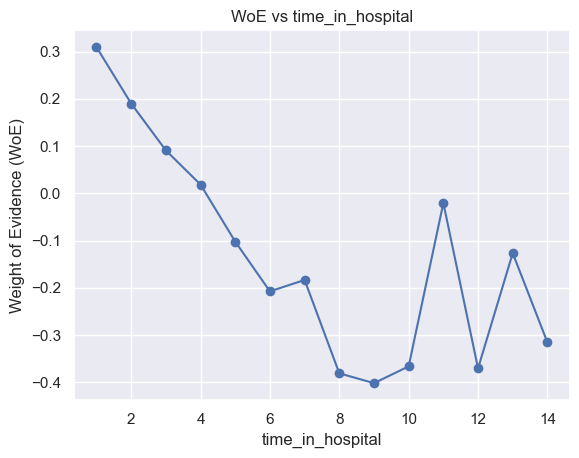

In [56]:
result = woe_discrete(X_train, y_train, 'time_in_hospital')

result_sorted = result.copy()
result_sorted['time_in_hospital'] = result_sorted['time_in_hospital'].astype(float)
result_sorted = result_sorted.sort_values('time_in_hospital')

plt.plot(result_sorted['time_in_hospital'], result_sorted['WoE'], marker='o')
plt.xlabel('time_in_hospital')
plt.ylabel('Weight of Evidence (WoE)')
plt.title('WoE vs time_in_hospital')
plt.show()  

In [57]:
def bin_time_in_hospital(x):
    if x >= 8:
        return 8      # small sample population from 8 onwards! should combine and clip to 8 max.
    else:
        return x

X_train['time_in_hospital'] = X_train['time_in_hospital'].apply(bin_time_in_hospital)

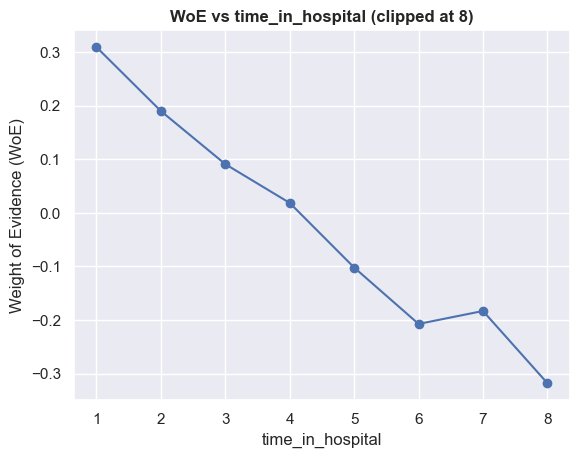

In [58]:
result = woe_discrete(X_train, y_train, 'time_in_hospital')

result_sorted = result.copy()
result_sorted['time_in_hospital'] = result_sorted['time_in_hospital'].astype(float)
result_sorted = result_sorted.sort_values('time_in_hospital')

plt.plot(result_sorted['time_in_hospital'], result_sorted['WoE'], marker='o')
plt.xlabel('time_in_hospital')
plt.ylabel('Weight of Evidence (WoE)')
plt.title('WoE vs time_in_hospital (clipped at 8)', fontsize=12, fontweight = 'bold')
plt.show()  

### Number of Diagnoses

In [59]:
woe_discrete(X_train, y_train, 'number_diagnoses')

,number_diagnoses,n_obs,prop_bad,prop_good,n_bad,n_good,prop_n_bad,prop_n_good,WoE,%Good - %Bad,IV,prop_total
0,1.0,131,0.022901,0.977099,3.0,128.0,0.000681,0.002851,1.431809,0.002170,0.029337,0.002657
1,2.0,597,0.050251,0.949749,30.0,567.0,0.006810,0.012629,0.617553,0.005819,0.029337,0.012109
2,3.0,1623,0.058534,0.941466,95.0,1528.0,0.021566,0.034034,0.456230,0.012468,0.029337,0.032920
3,4.0,3078,0.071150,0.928850,219.0,2859.0,0.049716,0.063681,0.247547,0.013964,0.029337,0.062433
4,5.0,6304,0.077253,0.922747,487.0,5817.0,0.110556,0.129566,0.158667,0.019010,0.029337,0.127868
5,6.0,5312,0.085655,0.914345,455.0,4857.0,0.103292,0.108183,0.046270,0.004892,0.029337,0.107746
6,7.0,5244,0.088863,0.911137,466.0,4778.0,0.105789,0.106424,0.005983,0.000635,0.029337,0.106367
7,8.0,5167,0.096187,0.903813,497.0,4670.0,0.112826,0.104018,-0.081284,-0.008808,0.029337,0.104805
8,9.0,21792,0.098522,0.901478,2147.0,19645.0,0.487401,0.437567,-0.107857,-0.049834,0.029337,0.442019
9,10.0,6,0.166667,0.833333,1.0,5.0,0.000227,0.000111,-0.712170,-0.000116,0.029337,0.000122


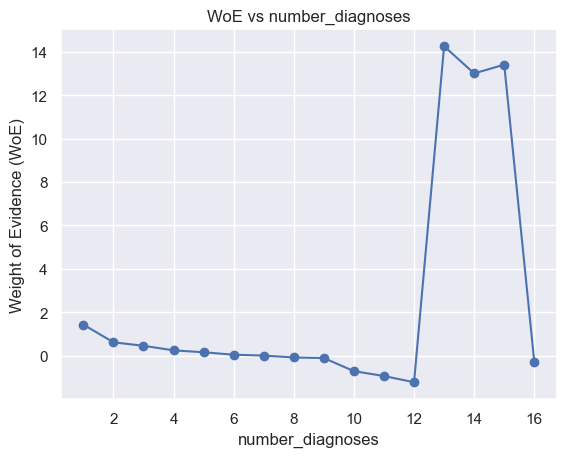

In [60]:
result = woe_discrete(X_train, y_train, 'number_diagnoses')

result_sorted = result.copy()
result_sorted['number_diagnoses'] = result_sorted['number_diagnoses'].astype(float)
result_sorted = result_sorted.sort_values('number_diagnoses')

plt.plot(result_sorted['number_diagnoses'], result_sorted['WoE'], marker='o')
plt.xlabel('number_diagnoses')
plt.ylabel('Weight of Evidence (WoE)')
plt.title('WoE vs number_diagnoses')
plt.show()   # SMALL SAMPLE SIZE from 10 onwards, random noise!!!!!

In [61]:
X_train['number_diagnoses'] = np.where(X_train['number_diagnoses'] >= 10, 10, X_train['number_diagnoses'])

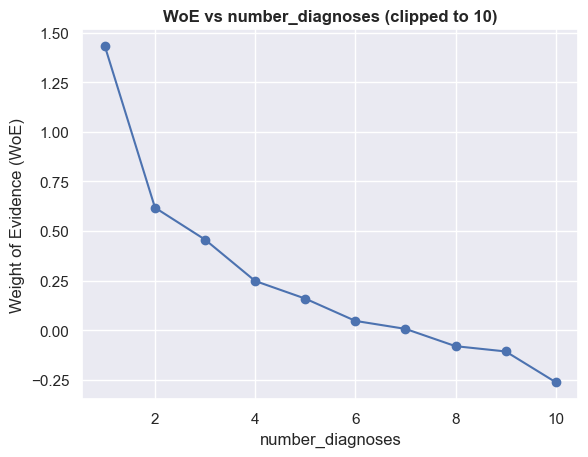

In [62]:
result = woe_discrete(X_train, y_train, 'number_diagnoses')

result_sorted = result.copy()
result_sorted['number_diagnoses'] = result_sorted['number_diagnoses'].astype(float)
result_sorted = result_sorted.sort_values('number_diagnoses')

plt.plot(result_sorted['number_diagnoses'], result_sorted['WoE'], marker='o')
plt.xlabel('number_diagnoses')
plt.ylabel('Weight of Evidence (WoE)')
plt.title('WoE vs number_diagnoses (clipped to 10)', fontsize=12, fontweight = 'bold')
plt.show()  

### Total number of procedures

In [63]:
woe_discrete(X_train, y_train, 'total_procedures_bin')

,total_procedures_bin,n_obs,prop_bad,prop_good,n_bad,n_good,prop_n_bad,prop_n_good,WoE,%Good - %Bad,IV,prop_total
0,"(1.999, 27.0]",4964,0.070105,0.929895,348.0,4616.0,0.079001,0.102815,0.263473,0.023814,0.021172,0.100688
1,"(27.0, 41.0]",5275,0.078483,0.921517,414.0,4861.0,0.093984,0.108272,0.141525,0.014288,0.021172,0.106996
2,"(41.0, 49.0]",5290,0.080718,0.919282,427.0,4863.0,0.096935,0.108317,0.111018,0.011382,0.021172,0.107300
3,"(49.0, 54.0]",4211,0.081691,0.918309,344.0,3867.0,0.078093,0.086132,0.097984,0.008039,0.021172,0.085414
4,"(54.0, 60.0]",5285,0.085147,0.914853,450.0,4835.0,0.102157,0.107693,0.052780,0.005537,0.021172,0.107199
5,"(60.0, 66.0]",5251,0.092744,0.907256,487.0,4764.0,0.110556,0.106112,-0.041030,-0.004444,0.021172,0.106509
6,"(66.0, 72.0]",4820,0.091286,0.908714,440.0,4380.0,0.099886,0.097559,-0.023579,-0.002328,0.021172,0.097767
7,"(72.0, 79.0]",4622,0.102986,0.897014,476.0,4146.0,0.108059,0.092347,-0.157127,-0.015712,0.021172,0.093751
8,"(79.0, 90.0]",4940,0.106275,0.893725,525.0,4415.0,0.119183,0.098338,-0.192244,-0.020844,0.021172,0.100201
9,"(90.0, 170.0]",4643,0.106397,0.893603,494.0,4149.0,0.112145,0.092414,-0.193521,-0.019732,0.021172,0.094177


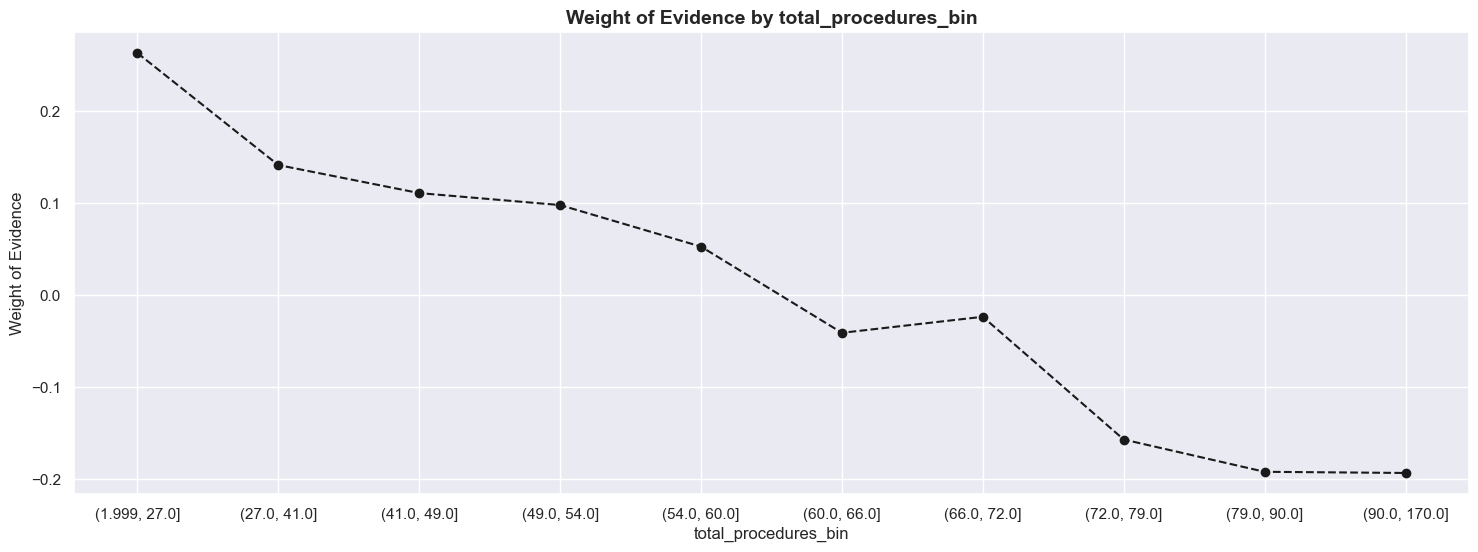

In [64]:
plot_by_woe(woe_discrete(X_train, y_train, 'total_procedures_bin'))

### Exploring more variables outside of IV < 0.02, but hold certain relationship

#### Insulin Change

Text(0.5, 1.0, '% of Readmission status by Insulin Change')

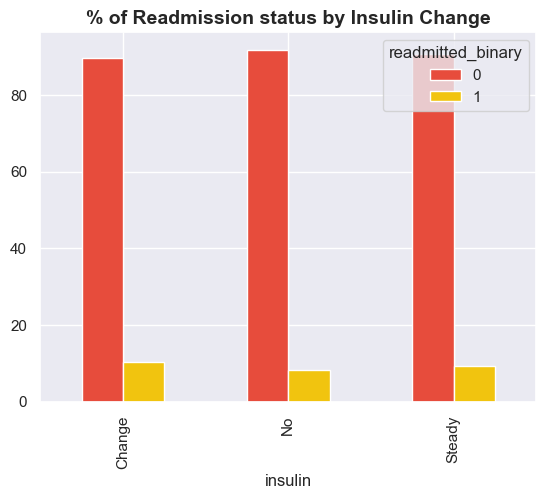

In [65]:
colors = ['#E74C3C','#F1C40F','#2ECC71']
readmit_race = pd.crosstab(X_train['insulin'], y_train, normalize='index') * 100
readmit_race.plot(kind='bar', stacked=False, color = colors)
plt.title('% of Readmission status by Insulin Change', fontsize=14, fontweight='bold')

In [66]:
### seems like not strictly ordinal, one-hot encode instead.

X_train = pd.get_dummies(X_train, columns=['insulin'], drop_first=True)

### Total number of emergency

In [67]:
X_train_1 = pd.concat([X_train, y_train], axis = 1)

Text(0, 0.5, 'Average Number of Emergency Visits')

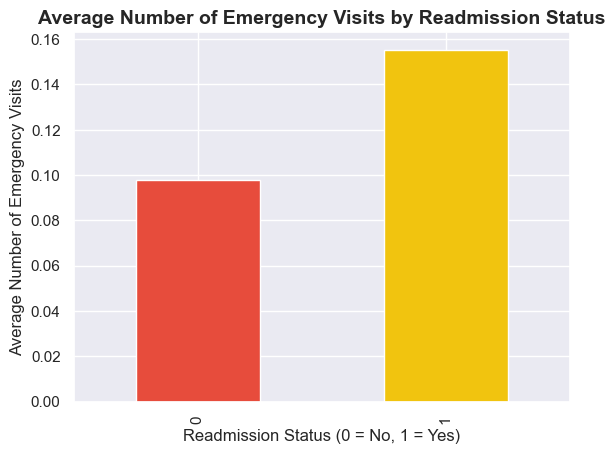

In [68]:
readmit_visits = X_train_1.groupby('readmitted_binary')['number_emergency'].mean()
readmit_visits.plot(kind='bar', color = colors)

plt.title('Average Number of Emergency Visits by Readmission Status', fontsize=14, fontweight='bold')
plt.xlabel('Readmission Status (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Average Number of Emergency Visits', fontsize=12)

In [69]:
pd.set_option("display.max_rows", 20)

In [70]:
woe_discrete(X_train, y_train, 'number_emergency')

,number_emergency,n_obs,prop_bad,prop_good,n_bad,n_good,prop_n_bad,prop_n_good,WoE,%Good - %Bad,IV,prop_total
0,0.0001,45744,0.086591,0.913409,3961.0,41783.0,0.899205,0.930662,0.034385,0.031457,0.024596,0.927851
1,1.0000,2697,0.119763,0.880237,323.0,2374.0,0.073326,0.052878,-0.326929,-0.020448,0.024596,0.054705
2,2.0000,557,0.123878,0.876122,69.0,488.0,0.015664,0.010870,-0.365400,-0.004794,0.024596,0.011298
3,3.0000,176,0.125000,0.875000,22.0,154.0,0.004994,0.003430,-0.375698,-0.001564,0.024596,0.003570
4,4.0000,66,0.257576,0.742424,17.0,49.0,0.003859,0.001091,-1.263001,-0.002768,0.024596,0.001339
5,5.0000,20,0.200000,0.800000,4.0,16.0,0.000908,0.000356,-0.935314,-0.000552,0.024596,0.000406
6,6.0000,19,0.210526,0.789474,4.0,15.0,0.000908,0.000334,-0.999852,-0.000574,0.024596,0.000385
7,7.0000,6,0.166667,0.833333,1.0,5.0,0.000227,0.000111,-0.712170,-0.000116,0.024596,0.000122
8,8.0000,6,0.333333,0.666667,2.0,4.0,0.000454,0.000089,-1.628460,-0.000365,0.024596,0.000122
9,9.0000,1,0.000000,1.000000,0.0,1.0,0.000000,0.000022,12.313751,0.000022,0.024596,0.000020


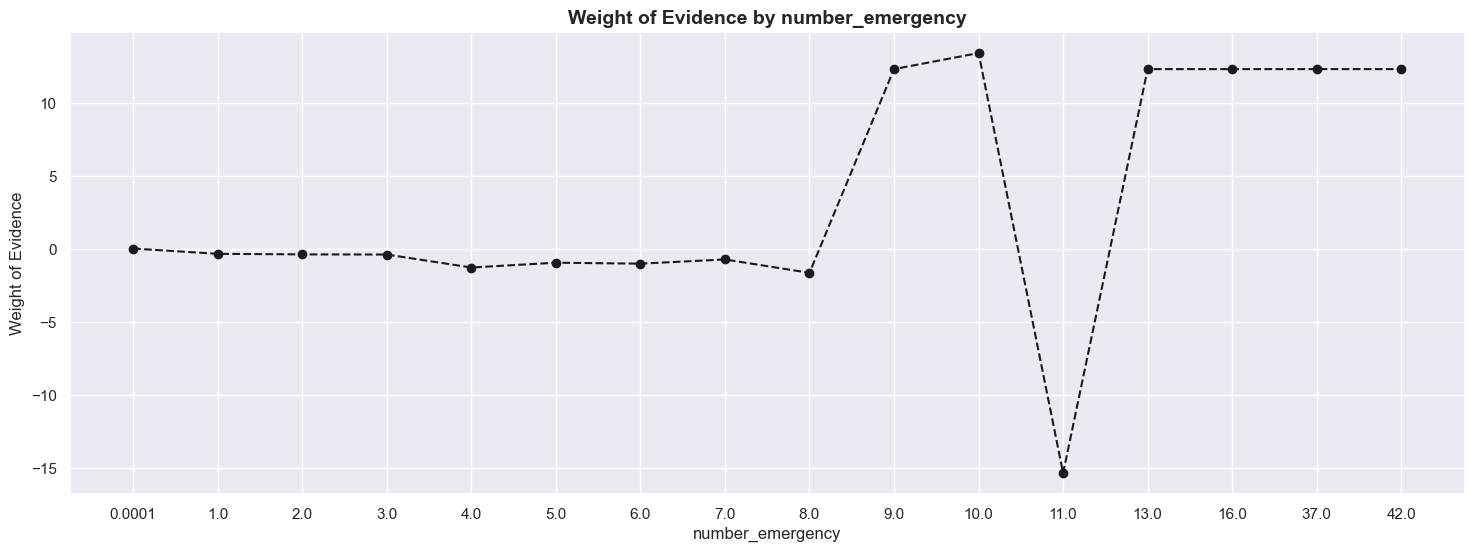

In [71]:
plot_by_woe(woe_discrete(X_train, y_train, 'number_emergency'))

In [72]:
X_train['number_emergency'] = np.where(X_train['number_emergency'] >= 4, 4, X_train['number_emergency'])

### Final X_Train

In [73]:
pd.set_option("display.max_rows", 50)

In [74]:
chosen = ['age_encoded', 'discharge_disposition_ord',
          'time_in_hospital number_inpatient_bin', 'num_medications number_inpatient_bin', 'number_inpatient number_diagnoses_bin', 'num_lab_procedures number_inpatient_bin',
          'number_inpatient', 
          'time_in_hospital', 'number_diagnoses', 'total_procedures_bin', 'number_emergency', 'insulin_No', 'insulin_Steady']

In [75]:
X_train = X_train[chosen]

In [76]:
X_train['total_procedures_ord'] = X_train['total_procedures_bin'].cat.codes
X_train['time_in_hospital number_inpatient_ord'] = X_train['time_in_hospital number_inpatient_bin'].cat.codes
X_train['num_medications number_inpatient_ord'] = X_train['num_medications number_inpatient_bin'].cat.codes
X_train['number_inpatient number_diagnoses_ord'] = X_train['number_inpatient number_diagnoses_bin'].cat.codes
X_train['num_lab_procedures number_inpatient_ord'] = X_train['num_lab_procedures number_inpatient_bin'].cat.codes

#### Apply Scaling

In [77]:
from sklearn.preprocessing import StandardScaler

In [78]:
numerical_cols_ordinal_cols = [
    'number_emergency',
    'number_diagnoses',
    'number_inpatient',
    'time_in_hospital',
    'age_encoded',               #  for comparative coefficient   
    'total_procedures_ord',
    'discharge_disposition_ord',
    'time_in_hospital number_inpatient_ord',
    'num_medications number_inpatient_ord',
    'number_inpatient number_diagnoses_ord',
    'num_lab_procedures number_inpatient_ord'
]

# Initialize scaler
scaler = StandardScaler()

# Fit scaler on TRAINING data only, then transform both train and test
X_train[numerical_cols_ordinal_cols] = scaler.fit_transform(X_train[numerical_cols_ordinal_cols])

#### Apply same transformation of Training onto Test

In [79]:
# Apply same transformation of Training onto Test

In [80]:
age_order = [
    '[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
    '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)'
]

# Create a mapping dictionary: bin → ordinal number
age_mapping = {age: i+1 for i, age in enumerate(age_order)}

# Apply the mapping
X_test['age_encoded'] = X_test['age'].map(age_mapping)

In [81]:
X_test['discharge_disposition_ord'] = X_test['discharge_disposition_category'].map(discharge_order)

In [82]:
X_test['number_inpatient'] = X_test['number_inpatient'].clip(upper=7)
X_test['time_in_hospital'] = X_test['time_in_hospital'].clip(upper=8)
X_test['number_diagnoses'] = X_test['number_diagnoses'].clip(upper=10)

In [83]:
bins = [i.left for i in X_train['total_procedures_bin'].cat.categories] + [X_train['total_procedures_bin'].cat.categories[-1].right]
X_test['total_procedures_bin'] = pd.cut(X_test['total_procedures'], bins=bins, include_lowest=True)
X_test['total_procedures_ord'] = X_test['total_procedures_bin'].cat.codes

In [84]:
bins = [i.left for i in X_train['time_in_hospital number_inpatient_bin'].cat.categories] + [X_train['time_in_hospital number_inpatient_bin'].cat.categories[-1].right]
X_test['time_in_hospital number_inpatient_bin'] = pd.cut(X_test['time_in_hospital number_inpatient'], bins=bins, include_lowest=True)
X_test['time_in_hospital number_inpatient_ord'] = X_test['time_in_hospital number_inpatient_bin'].cat.codes

In [85]:
bins = [i.left for i in X_train['num_medications number_inpatient_bin'].cat.categories] + [X_train['num_medications number_inpatient_bin'].cat.categories[-1].right]
X_test['num_medications number_inpatient_bin'] = pd.cut(X_test['num_medications number_inpatient'], bins=bins, include_lowest=True)
X_test['num_medications number_inpatient_ord'] = X_test['num_medications number_inpatient_bin'].cat.codes

In [86]:
bins = [i.left for i in X_train['number_inpatient number_diagnoses_bin'].cat.categories] + [X_train['number_inpatient number_diagnoses_bin'].cat.categories[-1].right]
X_test['number_inpatient number_diagnoses_bin'] = pd.cut(X_test['number_inpatient number_diagnoses'], bins=bins, include_lowest=True)
X_test['number_inpatient number_diagnoses_ord'] = X_test['number_inpatient number_diagnoses_bin'].cat.codes

In [87]:
bins = [i.left for i in X_train['num_lab_procedures number_inpatient_bin'].cat.categories] + [X_train['num_lab_procedures number_inpatient_bin'].cat.categories[-1].right]
X_test['num_lab_procedures number_inpatient_bin'] = pd.cut(X_test['num_lab_procedures number_inpatient'], bins=bins, include_lowest=True)
X_test['num_lab_procedures number_inpatient_ord'] = X_test['num_lab_procedures number_inpatient_bin'].cat.codes

In [88]:
X_test['number_emergency'] = np.where(X_test['number_emergency'] >= 4, 4, X_test['number_emergency'])

In [89]:
### seems like not strictly ordinal, one-hot encode instead.

X_test = pd.get_dummies(X_test, columns=['insulin'], drop_first=True)

In [90]:
X_train.drop(columns = ['total_procedures_bin'], axis = 1, inplace = True)

In [91]:
# apply same scaling from train to test for numerical variable for comparison
X_test[numerical_cols_ordinal_cols] = scaler.transform(X_test[numerical_cols_ordinal_cols])

In [92]:
X_train.drop(columns = ['time_in_hospital number_inpatient_bin', 'num_medications number_inpatient_bin' , 'number_inpatient number_diagnoses_bin', 'num_lab_procedures number_inpatient_bin'], axis = 1, inplace = True)

In [93]:
X_train

,age_encoded,discharge_disposition_ord,number_inpatient,time_in_hospital,number_diagnoses,number_emergency,insulin_No,insulin_Steady,total_procedures_ord,time_in_hospital number_inpatient_ord,num_medications number_inpatient_ord,number_inpatient number_diagnoses_ord,num_lab_procedures number_inpatient_ord
15796,0.592643,0.626167,-0.29591,-0.865092,0.386622,-0.24308,True,False,-0.150577,-1.063125,-0.828340,0.163673,-0.163563
91253,-1.908941,-0.536482,-0.29591,-0.865092,-2.134121,-0.24308,False,True,0.198604,-1.063125,-1.521832,-1.747447,0.531834
3377,0.592643,1.788816,-0.29591,0.427773,0.890771,-0.24308,False,False,0.896967,0.169081,0.211897,0.641452,0.879533
16822,-0.032753,0.626167,-0.29591,1.720639,-0.117527,-0.24308,True,False,1.595331,0.990552,1.252135,-0.314107,0.184136
57752,-0.032753,-0.536482,-0.29591,-0.434137,-0.621675,-0.24308,True,False,0.198604,-0.652390,1.252135,-0.791887,-1.206659
...,...,...,...,...,...,...,...,...,...,...,...,...,...
819,-1.283545,-0.536482,-0.29591,-0.865092,-2.134121,-0.24308,False,False,-0.499759,-1.063125,0.211897,-1.747447,-0.858961
31852,-1.283545,-0.536482,-0.29591,0.427773,-1.125824,-0.24308,False,True,0.896967,0.169081,-0.828340,-1.269667,0.879533
92538,-0.032753,-0.536482,-0.29591,1.720639,0.890771,-0.24308,False,False,1.595331,1.401287,1.252135,0.641452,0.531834
45895,0.592643,-0.536482,-0.29591,-1.296048,0.890771,-0.24308,True,False,-1.198122,-1.063125,-0.828340,0.641452,-1.206659


In [94]:
col_in_X_train = X_train.columns

In [95]:
X_test = X_test[col_in_X_train]

In [96]:
X_train = X_train.astype({col: int for col in X_train.select_dtypes(bool).columns})
X_test  = X_test.astype({col: int for col in X_test.select_dtypes(bool).columns})

In [97]:
X_train.shape

(49301, 13)

In [98]:
X_test.shape

(21130, 13)

In [99]:
# Compute Pearson correlation (linear relationships)
pearson_corr = X_train.corr(method='pearson')

# Compute Spearman correlation (monotonic relationships)
spearman_corr = X_train.corr(method='spearman')

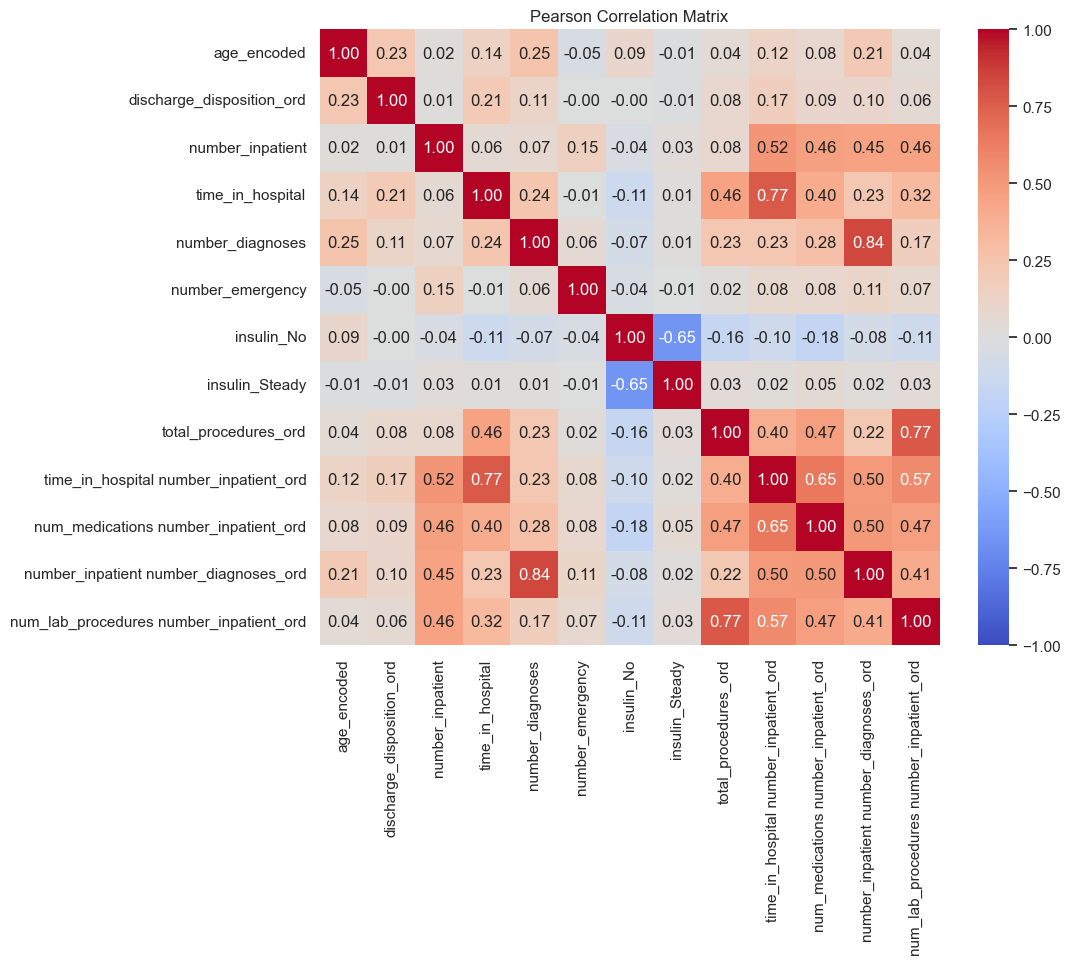

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Pearson Correlation Matrix")
plt.show()

In [101]:
X_train.drop(['time_in_hospital', 'number_diagnoses'], axis = 1, inplace = True)
X_test.drop(['time_in_hospital', 'number_diagnoses'], axis = 1, inplace = True)

# remove high collinearity, and we choose interactive terms over the raw as it has higher IV and stronger behavioural prediction

### First Run in stepwise

In [102]:
import statsmodels.api as sm

X_train_const = sm.add_constant(X_train)
X_test_const  = sm.add_constant(X_test)

logit_model = sm.Logit(y_train, X_train_const)
result = logit_model.fit(disp=False)

In [103]:
print(result.summary())

                           Logit Regression Results                           
Dep. Variable:      readmitted_binary   No. Observations:                49301
Model:                          Logit   Df Residuals:                    49289
Method:                           MLE   Df Model:                           11
Date:                Sun, 09 Nov 2025   Pseudo R-squ.:                 0.03307
Time:                        16:07:46   Log-Likelihood:                -14350.
converged:                       True   LL-Null:                       -14841.
Covariance Type:            nonrobust   LLR p-value:                1.800e-203
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
const                                      -2.2904      0.035    -65.574      0.000      -2.359      -2.222
age_encoded                                 

#### Drop the highly statistically insignificant 'total_procedures_ord' variable

In [104]:
X_train.drop(['total_procedures_ord'], axis = 1, inplace = True)
X_test.drop(['total_procedures_ord'], axis = 1, inplace = True)

### 2nd Run

In [105]:
import statsmodels.api as sm

X_train_const = sm.add_constant(X_train)
X_test_const  = sm.add_constant(X_test)

logit_model = sm.Logit(y_train, X_train_const)
result = logit_model.fit(disp=False)

In [106]:
print(result.summary())

                           Logit Regression Results                           
Dep. Variable:      readmitted_binary   No. Observations:                49301
Model:                          Logit   Df Residuals:                    49290
Method:                           MLE   Df Model:                           10
Date:                Sun, 09 Nov 2025   Pseudo R-squ.:                 0.03302
Time:                        16:07:47   Log-Likelihood:                -14351.
converged:                       True   LL-Null:                       -14841.
Covariance Type:            nonrobust   LLR p-value:                3.577e-204
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
const                                      -2.2858      0.035    -65.894      0.000      -2.354      -2.218
age_encoded                                 

#### Drop the highly statistically insignificant 'num_lab_procedures number_inpatient_ord' variable

In [107]:
X_train.drop(['num_lab_procedures number_inpatient_ord'], axis = 1, inplace = True)
X_test.drop(['num_lab_procedures number_inpatient_ord'], axis = 1, inplace = True)

### 3rd Run

In [108]:
import statsmodels.api as sm

X_train_const = sm.add_constant(X_train)
X_test_const  = sm.add_constant(X_test)

logit_model = sm.Logit(y_train, X_train_const)
result = logit_model.fit(disp=False)

In [109]:
print(result.summary())

                           Logit Regression Results                           
Dep. Variable:      readmitted_binary   No. Observations:                49301
Model:                          Logit   Df Residuals:                    49291
Method:                           MLE   Df Model:                            9
Date:                Sun, 09 Nov 2025   Pseudo R-squ.:                 0.03300
Time:                        16:07:49   Log-Likelihood:                -14351.
converged:                       True   LL-Null:                       -14841.
Covariance Type:            nonrobust   LLR p-value:                4.738e-205
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                    -2.2852      0.035    -65.887      0.000      -2.353      -2.217
age_encoded                               0.0703  

#### Drop the highly statistically insignificant 'num_medications number_inpatient_ord' variable

In [110]:
X_train.drop(['num_medications number_inpatient_ord'], axis = 1, inplace = True)
X_test.drop(['num_medications number_inpatient_ord'], axis = 1, inplace = True)

### 4th Run (Final Regression Model!)

In [111]:
import statsmodels.api as sm

X_train_const = sm.add_constant(X_train)
X_test_const  = sm.add_constant(X_test)

logit_model = sm.Logit(y_train, X_train_const)
result = logit_model.fit(disp=False)

In [112]:
print(result.summary())

                           Logit Regression Results                           
Dep. Variable:      readmitted_binary   No. Observations:                49301
Model:                          Logit   Df Residuals:                    49292
Method:                           MLE   Df Model:                            8
Date:                Sun, 09 Nov 2025   Pseudo R-squ.:                 0.03294
Time:                        16:07:50   Log-Likelihood:                -14352.
converged:                       True   LL-Null:                       -14841.
Covariance Type:            nonrobust   LLR p-value:                9.940e-206
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                    -2.2795      0.034    -66.261      0.000      -2.347      -2.212
age_encoded                               0.0696  

In [113]:
y_pred_prob = result.predict(X_train_const)

In [114]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

print("Training AUC:", roc_auc_score(y_train, y_pred_prob))

Training AUC: 0.6372204006049952


In [115]:
y_pred_prob = result.predict(X_test_const)

In [116]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

print("Testing AUC:", roc_auc_score(y_test, y_pred_prob))

Testing AUC: 0.6371299860034282


In [117]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = pd.DataFrame()
vif["VIF"] = [variance_inflation_factor(X_train_const.values, i)
              for i in range(X_train_const.shape[1])]
vif["variable"] = X_train_const.columns
print(vif)

        VIF                               variable
0  5.101659                                  const
1  1.130987                            age_encoded
2  1.086010              discharge_disposition_ord
3  1.519465                       number_inpatient
4  1.033011                       number_emergency
5  1.822065                             insulin_No
6  1.777735                         insulin_Steady
7  1.612400  time_in_hospital number_inpatient_ord
8  1.500003  number_inpatient number_diagnoses_ord


In [118]:
import numpy as np
from sklearn.metrics import precision_recall_curve, f1_score

# y_pred_prob is from statsmodels
print(np.quantile(y_pred_prob, [0, 0.25, 0.5, 0.75, 0.9, 0.99]))
# just to see the probability range — usually all below 0.5 for imbalanced data

# compute precision, recall, thresholds
prec, rec, thr = precision_recall_curve(y_test, y_pred_prob, pos_label=1)

# compute F1 for each threshold (align properly)
f1 = 2 * prec[1:] * rec[1:] / (prec[1:] + rec[1:] + 1e-12)

best_idx = np.nanargmax(f1)
best_thr = thr[best_idx]

print("Best F1:", f1[best_idx])
print("Best threshold:", best_thr)


[0.04069281 0.06213596 0.07390436 0.11038651 0.14756642 0.25005566]
Best F1: 0.22688736374608845
Best threshold: 0.10780246126236086


In [119]:
y_pred = (y_pred_prob >= 0.10780246126236086).astype(int)

In [120]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[14538  4704]
 [ 1045   843]]


In [121]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.76      0.83     19242
           1       0.15      0.45      0.23      1888

    accuracy                           0.73     21130
   macro avg       0.54      0.60      0.53     21130
weighted avg       0.86      0.73      0.78     21130



### Class-Balanced Model Performance

In [122]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

#### Cross-Validation

In [123]:
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train, y_train)

from sklearn.model_selection import cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

cv_results = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring)

for metric in scoring.keys():
    print(f"{metric} scores: {cv_results['test_' + metric]}")
    print(f"Mean {metric}: {cv_results['test_' + metric].mean():.4f}")
    print()

accuracy scores: [0.66839063 0.67535497 0.67292089 0.67302231 0.66947262]
Mean accuracy: 0.6718

precision scores: [0.14139898 0.14197531 0.13692689 0.13942752 0.13460356]
Mean precision: 0.1389

recall scores: [0.53461975 0.52213394 0.50170261 0.51418842 0.49716232]
Mean recall: 0.5140

f1 scores: [0.22364672 0.22324678 0.2151375  0.21937046 0.21185006]
Mean f1: 0.2187

roc_auc scores: [0.64115489 0.6433304  0.6326843  0.63767229 0.6264503 ]
Mean roc_auc: 0.6363



#### Test Results of model performance

In [124]:
y_pred = model.predict(X_train)
y_pred_proba = model.predict_proba(X_train)[:, 1]

# Metrics
accuracy = accuracy_score(y_train, y_pred)
precision = precision_score(y_train, y_pred)
recall = recall_score(y_train, y_pred)
f1 = f1_score(y_train, y_pred)
roc_auc = roc_auc_score(y_train, y_pred_proba)

# Print results
print("Model Performance Metrics for training:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}\n")

print("Classification Report:")
print(classification_report(y_train, y_pred, digits=4))

Model Performance Metrics for training:
Accuracy : 0.6731
Precision: 0.1393
Recall   : 0.5135
F1-Score : 0.2192
ROC-AUC  : 0.6374

Classification Report:
              precision    recall  f1-score   support

           0     0.9352    0.6888    0.7933     44896
           1     0.1393    0.5135    0.2192      4405

    accuracy                         0.6731     49301
   macro avg     0.5373    0.6011    0.5062     49301
weighted avg     0.8641    0.6731    0.7420     49301



In [125]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Print results
print("Model Performance Metrics:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}\n")

print("Classification Report for testing:")
print(classification_report(y_test, y_pred, digits=4))

Model Performance Metrics:
Accuracy : 0.6614
Precision: 0.1392
Recall   : 0.5381
F1-Score : 0.2212
ROC-AUC  : 0.6374

Classification Report for testing:
              precision    recall  f1-score   support

           0     0.9370    0.6735    0.7837     19242
           1     0.1392    0.5381    0.2212      1888

    accuracy                         0.6614     21130
   macro avg     0.5381    0.6058    0.5024     21130
weighted avg     0.8657    0.6614    0.7334     21130



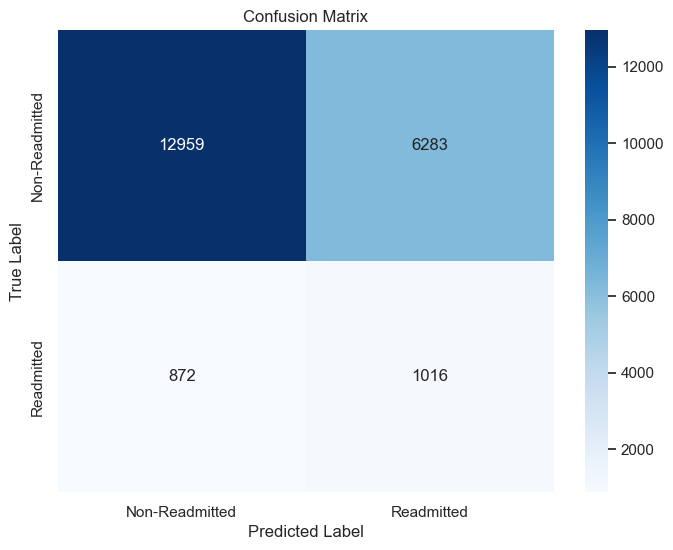

In [126]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Readmitted', 'Readmitted'],
    yticklabels=['Non-Readmitted', 'Readmitted']
)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [127]:
coefficients = pd.DataFrame({
    'Variable': X_train.columns,
    'Coefficient': model.coef_[0],  # This is your β values
    'Abs_Coefficient': abs(model.coef_[0])
})

# Sort by absolute value to see most important features
coefficients = coefficients.sort_values('Abs_Coefficient', ascending=False)

print(coefficients)

# Get intercept
print(f"\nIntercept: {model.intercept_[0]}")

                                Variable  Coefficient  Abs_Coefficient
1              discharge_disposition_ord     0.280660         0.280660
4                             insulin_No    -0.218568         0.218568
2                       number_inpatient     0.150262         0.150262
6  time_in_hospital number_inpatient_ord     0.115392         0.115392
5                         insulin_Steady    -0.109018         0.109018
0                            age_encoded     0.087030         0.087030
3                       number_emergency     0.073463         0.073463
7  number_inpatient number_diagnoses_ord     0.061353         0.061353

Intercept: 0.05067128536803759


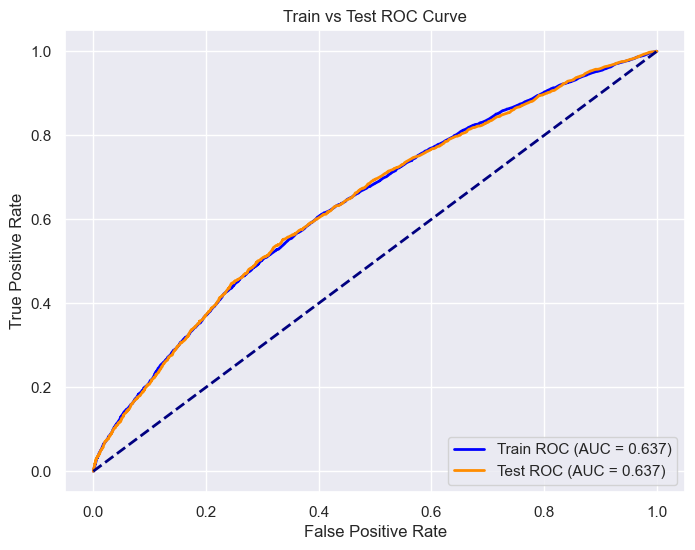

In [128]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_pred_proba_train = model.predict_proba(X_train)[:, 1]
y_pred_proba_test = model.predict_proba(X_test)[:, 1]

fpr_train, tpr_train, _ = roc_curve(y_train, y_pred_proba_train)
fpr_test, tpr_test, _ = roc_curve(y_test, y_pred_proba_test)

auc_train = roc_auc_score(y_train, y_pred_proba_train)
auc_test = roc_auc_score(y_test, y_pred_proba_test)

plt.figure(figsize=(8,6))
plt.plot(fpr_train, tpr_train, color='blue', lw=2,
         label=f'Train ROC (AUC = {auc_train:.3f})')
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2,
         label=f'Test ROC (AUC = {auc_test:.3f})')

# Diagonal reference line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Train vs Test ROC Curve')
plt.legend(loc='lower right')
plt.show()